<a href="https://colab.research.google.com/github/vivek-bhushan/vivek-bhushan-IITM-WEEK27/blob/main/Week27_Graded_Mini_Project_%5BVivek-Bhushan%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 27 Graded Mini Project
## Policy Assistant Agent (Single + Memory + Graph)

**Submitted by Vivek Bhushan**

### Objective
In this project, I built a grounded Policy Assistant that answers employee questions from a local policy corpus. I focused on retrieval, exact document citations, quotation support, bad-ID recovery, critic-verified memory, graph routing, explicit budgets, and reproducible evaluation.

I kept the implementation deliberately small and inspectable. As in my Week 19 project, every task is separated so that the code, output, and my observations can be reviewed in sequence.

> **Google Colab:** choose **Runtime → Run all**. The notebook installs FAISS when needed and recreates all project files, including the supplied dataset, so it can run independently.

# Setup & Libraries
This section initializes our environment and imports the baseline libraries needed for the project.

## Project Overview

```text
User question
    ↓
plan → memory_read → agent_answer → critic → memory_write → stop
                         ↑              |
                         └── one retry ─┘
```

| Component | Main purpose | My design choice |
|---|---|---|
| FAISS retriever | Find relevant policies | Local TF-IDF vectors with normalized inner-product search |
| Tools | Search and read full records | Typed result objects and `PolicyNotFoundError` |
| Agent | Use tools and answer from evidence | Deterministic extractive ReAct-style flow |
| Memory | Reuse verified hints | Write only after critic approval and a valid citation |
| Critic | Enforce acceptance | Check IDs, quotation presence, and source support |
| Graph | Control routing | Explicit node budget and only one critic retry |

In [20]:
# ======================================================================
# Standard Library Imports
# ======================================================================
import sys
import json
import time
import re
import csv
import subprocess
import importlib.util
from pathlib import Path
from dataclasses import dataclass, field

# ======================================================================
# Automatic Dependency Installation
# ======================================================================
packages = []
if importlib.util.find_spec("faiss") is None:
    packages.append("faiss-cpu==1.9.0.post1")
if importlib.util.find_spec("sklearn") is None:
    packages.append("scikit-learn>=1.4,<2")
if packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

# ======================================================================
# Third-Party Library Imports
# ======================================================================
# Scientific computing & vector search utilities
import faiss
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer

# Task 1.1 — Environment and Data Preparation
I first install the lightweight dependencies. I use CPU FAISS because the corpus has only ten short records; a GPU is not necessary.

In [21]:
import sys, subprocess, importlib.util
packages = []
if importlib.util.find_spec("faiss") is None:
    packages.append("faiss-cpu==1.9.0.post1")
if importlib.util.find_spec("sklearn") is None:
    packages.append("scikit-learn>=1.4,<2")
if importlib.util.find_spec("pytest") is None:
    packages.append("pytest>=8,<9")
if packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
print("Environment ready")

Environment ready


### Bootstrap the project files
The next cell writes the exact supplied policy records and the same modular source files included in the ZIP. This makes the notebook portable: it works even when the notebook is uploaded to Colab without separately uploading the repository.

In [22]:
from pathlib import Path
import json
PROJECT = Path.cwd()
FILES = {'policies.jsonl': '{"doc_id": "remote_work_v3", "text": "Remote Work Policy (v3): Employees in eligible roles may work remotely up to 2 days per week. Any request to exceed 2 remote days per week requires written approval from the employee\'s manager and HR Business Partner. Remote work days must be logged in the HR portal by Friday of each week. Employees on a Performance Improvement Plan (PIP) are not eligible for remote work until the PIP is closed.", "date": "2024-01-15"}\n{"doc_id": "leave_policy_v2", "text": "Annual Leave Policy (v2): All full-time employees are entitled to 18 annual leave days per calendar year, accrued monthly at 1.5 days/month. A maximum of 5 unused annual leave days may be carried over into the next calendar year, and carried-over days must be used by March 31 or they are forfeited. Annual leave requests must be submitted at least 3 working days in advance via the HR portal.", "date": "2023-11-01"}\n{"doc_id": "leave_policy_v1", "text": "Annual Leave Policy (v1, superseded): All full-time employees are entitled to 15 annual leave days per calendar year. No carry-over of unused leave is permitted; unused days lapse on December 31. This version has been superseded by leave_policy_v2.", "date": "2022-06-01"}\n{"doc_id": "travel_expense_v4", "text": "Travel & Expense Policy (v4): While travelling on approved company business, the meal allowance is capped at INR 1500 per day within India and USD 60 per day for international travel. Original itemised receipts are mandatory for any single meal claim exceeding INR 500; claims below this threshold may use a self-certified expense line. Alcohol is not reimbursable under any circumstance.", "date": "2024-03-10"}\n{"doc_id": "security_mfa_v1", "text": "Information Security Policy (v1): Multi-Factor Authentication (MFA) is mandatory for all VPN connections into the corporate network, for all SaaS applications holding customer data, and for privileged administrator accounts. New employees must enroll in MFA within 7 days of their start date. Any exception to MFA enforcement requires sign-off from the Chief Information Security Officer (CISO).", "date": "2023-08-20"}\n{"doc_id": "password_policy_v2", "text": "Password Policy (v2): Corporate account passwords must be at least 14 characters long and include a mix of uppercase, lowercase, numbers, and symbols. Passwords must be rotated every 180 days and must not match any of the previous 10 passwords used. Password sharing between employees is strictly prohibited and is a terminable offense.", "date": "2023-05-12"}\n{"doc_id": "laptop_equipment_v1", "text": "Laptop & Equipment Policy (v1): The company issues one standard laptop per employee, refreshed every 3 years. Employees relocating to a fully remote role may request a one-time home-office equipment stipend of INR 15000, subject to manager approval and submission of receipts within 30 days of purchase.", "date": "2023-02-18"}\n{"doc_id": "data_retention_v2", "text": "Data Retention Policy (v2): Customer personal data must not be retained for longer than 24 months after the last active engagement unless required by law or an active contractual obligation. Internal HR records, including leave and performance data, are retained for 7 years from the employee\'s last day of employment.", "date": "2023-09-05"}\n{"doc_id": "expense_approval_v1", "text": "Expense Approval Policy (v1): Any single expense claim above INR 25000 requires pre-approval from a Director-level manager before the expense is incurred. Claims are processed within 10 business days of submission through the Finance portal, provided all receipts and cost-center codes are attached.", "date": "2022-12-01"}\n{"doc_id": "vpn_access_v2", "text": "VPN Access Policy (v2): VPN access is granted only to employees whose role requires connectivity to internal systems outside the office network. Access requests must be approved by the employee\'s manager and provisioned by IT within 2 business days. VPN sessions automatically time out after 30 minutes of inactivity and require MFA re-authentication as described in the Information Security Policy.", "date": "2024-02-01"}\n', 'requirements.txt': 'faiss-cpu==1.9.0.post1\nnumpy>=1.26,<3\nscikit-learn>=1.4,<2\npytest>=8,<9\n', 'policy_assistant/__init__.py': 'from .tools import PolicyTools, PolicyNotFoundError\nfrom .agent import PolicyAgent\nfrom .critic import GroundingCritic\nfrom .memory import VerifiedFactMemory\nfrom .graph import PolicyGraph\n__all__ = ["PolicyTools", "PolicyNotFoundError", "PolicyAgent", "GroundingCritic", "VerifiedFactMemory", "PolicyGraph"]\n', 'policy_assistant/tools.py': 'import json\nfrom dataclasses import dataclass\nfrom pathlib import Path\nimport faiss\nimport numpy as np\nfrom sklearn.feature_extraction.text import TfidfVectorizer\n\nclass PolicyNotFoundError(Exception):\n    def __init__(self, doc_id):\n        self.doc_id = doc_id\n        super().__init__(f"Policy document not found: {doc_id}")\n\n@dataclass(frozen=True)\nclass PolicyDocument:\n    doc_id: str\n    text: str\n    date: str\n\n@dataclass(frozen=True)\nclass SearchHit:\n    doc_id: str\n    score: float\n    date: str\n    preview: str\n\nclass PolicyTools:\n    def __init__(self, dataset_path="policies.jsonl"):\n        rows = [json.loads(line) for line in Path(dataset_path).read_text(encoding="utf-8").splitlines() if line.strip()]\n        required = {"doc_id", "text", "date"}\n        if not rows or any(not required.issubset(row) for row in rows):\n            raise ValueError("Each policy row must contain doc_id, text, and date")\n        self.documents = [PolicyDocument(row["doc_id"], row["text"], row["date"]) for row in rows]\n        self.by_id = {document.doc_id: document for document in self.documents}\n        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words="english", sublinear_tf=True)\n        vectors = np.ascontiguousarray(self.vectorizer.fit_transform(d.text for d in self.documents).toarray().astype("float32"))\n        faiss.normalize_L2(vectors)\n        self.index = faiss.IndexFlatIP(vectors.shape[1])\n        self.index.add(vectors)\n\n    def policy_search(self, query, k=3):\n        if not query.strip() or k < 1:\n            return []\n        vector = np.ascontiguousarray(self.vectorizer.transform([query]).toarray().astype("float32"))\n        if not np.any(vector):\n            return []\n        faiss.normalize_L2(vector)\n        scores, indices = self.index.search(vector, len(self.documents))\n        hits = []\n        for score, index in zip(scores[0], indices[0]):\n            if index < 0 or score <= 0:\n                continue\n            document = self.documents[int(index)]\n            adjusted = float(score) * (0.25 if "superseded" in document.text.lower() else 1.0)\n            hits.append(SearchHit(document.doc_id, adjusted, document.date, document.text[:180]))\n        hits.sort(key=lambda hit: (hit.score, hit.date, hit.doc_id), reverse=True)\n        return hits[:k]\n\n    def read_policy(self, doc_id):\n        if doc_id not in self.by_id:\n            raise PolicyNotFoundError(doc_id)\n        return self.by_id[doc_id]\n\n    @staticmethod\n    def safe_divide(numerator, denominator):\n        if denominator == 0:\n            raise ZeroDivisionError("Cannot divide by zero")\n        return numerator / denominator\n', 'policy_assistant/agent.py': 'import re\nfrom dataclasses import dataclass, field\nfrom .tools import PolicyNotFoundError\n\n@dataclass\nclass AgentResult:\n    answer: str\n    citations: list[str]\n    quotes: list[str]\n    trace: list[dict] = field(default_factory=list)\n    steps: int = 0\n    stopped_reason: str = "completed"\n\nclass PolicyAgent:\n    def __init__(self, tools, max_steps=4):\n        self.tools, self.max_steps = tools, max_steps\n\n    @staticmethod\n    def _tokens(text):\n        stop = {"what","when","where","which","does","must","with","from","have","about","policy","employee","employees","company","will","would","could","should","into","only","than","that","this","your","their","they","them","under","after","before","more","much","many","long"}\n        return {x for x in re.findall(r"[a-z0-9]+", text.lower()) if len(x)>2 and x not in stop}\n\n    def _select(self, question, document):\n        body = document.text.split(":", 1)[-1].strip()\n        sentences = [x.strip() for x in re.split(r"(?<=[.!?])\\s+", body) if x.strip()]\n        query = self._tokens(question)\n        ranked = sorted(((len(query & self._tokens(s)), -i, s) for i,s in enumerate(sentences)), reverse=True)\n        return [s for overlap,_,s in ranked if overlap > 0][:2] or ([ranked[0][2]] if ranked else [])\n\n    def answer(self, question, hint=None, forced_doc_id=None):\n        trace, documents, steps = [], [], 0\n        requested = forced_doc_id\n        match = re.search(r"(?:doc(?:ument)?[_ -]?id|policy id)\\s*[:=]?\\s*([a-z0-9_]+)", question, re.I)\n        requested = requested or (match.group(1) if match else None)\n        if requested and steps < self.max_steps:\n            steps += 1\n            try:\n                doc = self.tools.read_policy(requested); documents.append(doc)\n                trace.append({"thought":"Read the supplied ID first.","action":f"read_policy({requested})","observation":doc.text})\n            except PolicyNotFoundError as error:\n                trace.append({"thought":"Fail softly, then recover with search.","action":f"read_policy({requested})","observation":{"error":type(error).__name__,"message":str(error)}})\n        if not documents and hint and hint.get("doc_ids") and steps < self.max_steps:\n            steps += 1\n            try:\n                doc = self.tools.read_policy(hint["doc_ids"][0]); documents.append(doc)\n                trace.append({"thought":"Validate the cheapest memory hint against source.","action":f"read_policy({doc.doc_id})","observation":doc.text})\n            except PolicyNotFoundError:\n                pass\n        if not documents and steps < self.max_steps:\n            steps += 1\n            hits = self.tools.policy_search(question, 3)\n            trace.append({"thought":"Search the local corpus for grounded candidates.","action":f"policy_search({question!r}, k=3)","observation":[h.__dict__ for h in hits]})\n            for hit in hits[:2]:\n                if steps >= self.max_steps: break\n                steps += 1\n                doc = self.tools.read_policy(hit.doc_id); documents.append(doc)\n                trace.append({"thought":"Read a top candidate before answering.","action":f"read_policy({hit.doc_id})","observation":doc.text})\n        latest, seen = [], set()\n        for doc in sorted(documents, key=lambda d:d.date, reverse=True):\n            family = re.sub(r"_v\\d+$", "", doc.doc_id)\n            if "superseded" in doc.text.lower() or family in seen: continue\n            latest.append(doc); seen.add(family)\n        if not latest:\n            return AgentResult("I could not find supporting policy in the local corpus.",[],[],trace,steps,"no_evidence")\n        parts, citations, quotes = [], [], []\n        for doc in latest:\n            selected = self._select(question, doc)\n            if not selected: continue\n            words = selected[0].rstrip(".").split()\n            quote = " ".join(words[:18]) + ("..." if len(words)>18 else "")\n            parts.append(f"{\' \'.join(selected)} [{doc.doc_id}] Supporting text: \\"{quote}\\" [{doc.doc_id}]")\n            citations.append(doc.doc_id); quotes.append(quote)\n        return AgentResult(" ".join(parts), citations, quotes, trace, steps)\n', 'policy_assistant/critic.py': 'import re\nclass GroundingCritic:\n    def __init__(self, tools): self.tools = tools\n    def evaluate(self, result):\n        issues=[]; ids=re.findall(r"\\[([a-z0-9_]+)\\]", result.answer)\n        if not ids: issues.append("missing_doc_id")\n        if not result.quotes or \'"\' not in result.answer: issues.append("missing_quote")\n        for doc_id in dict.fromkeys(ids):\n            try: source=" ".join(self.tools.read_policy(doc_id).text.lower().split())\n            except Exception: issues.append(f"unknown_doc_id:{doc_id}"); continue\n            if not any(q.lower().replace("...","") in source for q in result.quotes):\n                issues.append(f"quote_not_supported:{doc_id}")\n        return {"valid":not issues,"issues":issues}\n', 'policy_assistant/memory.py': 'import faiss\nimport numpy as np\nfrom sklearn.feature_extraction.text import HashingVectorizer\nclass VerifiedFactMemory:\n    def __init__(self, dimension=512):\n        self.vectorizer=HashingVectorizer(n_features=dimension,alternate_sign=False,norm="l2")\n        self.index=faiss.IndexFlatIP(dimension); self.entries=[]\n    def _vector(self,text): return np.ascontiguousarray(self.vectorizer.transform([text]).toarray().astype("float32"))\n    def write(self,question,result,critic_valid):\n        if not critic_valid or not result.citations: return False\n        self.index.add(self._vector(question)); self.entries.append({"question":question,"answer":result.answer,"doc_ids":list(result.citations)}); return True\n    def read(self,question,threshold=.65):\n        if not self.entries: return None\n        scores,indices=self.index.search(self._vector(question),1)\n        if indices[0][0]<0 or scores[0][0]<threshold: return None\n        entry=dict(self.entries[int(indices[0][0])]); entry["score"]=float(scores[0][0]); return entry\n', 'policy_assistant/graph.py': 'from dataclasses import dataclass\n@dataclass\nclass GraphResult:\n    question:str; answer:str; critic:dict; trace:list; graph_steps:int; agent_steps:int; retries:int; memory_hit:bool; stopped_reason:str\nclass PolicyGraph:\n    def __init__(self,agent,critic,memory,max_graph_steps=8,max_retries=1):\n        self.agent,self.critic,self.memory=agent,critic,memory\n        self.max_graph_steps,self.max_retries=max_graph_steps,max_retries\n    def run(self,question,forced_doc_id=None):\n        trace=[]; steps=0; retries=0; result=None; verdict=None\n        def visit(node,details):\n            nonlocal steps\n            if steps>=self.max_graph_steps:return False\n            steps+=1; trace.append({"node":node,"details":details}); return True\n        if not visit("plan",{"route":"memory_read -> agent_answer -> critic"}): return self._budget(question,trace,steps)\n        if not visit("memory_read",{}): return self._budget(question,trace,steps)\n        hint=self.memory.read(question); memory_hit=hint is not None; trace[-1]["details"]={"hit":memory_hit,"hint":hint}\n        while True:\n            if not visit("agent_answer",{"retry":retries}): return self._budget(question,trace,steps,result)\n            result=self.agent.answer(question,hint,forced_doc_id if retries==0 else None)\n            trace.extend({"node":"agent_trace","details":x} for x in result.trace)\n            if not visit("critic",{}): return self._budget(question,trace,steps,result)\n            verdict=self.critic.evaluate(result); trace[-1]["details"]=verdict\n            if verdict["valid"] or retries>=self.max_retries:break\n            retries+=1; hint=None; forced_doc_id=None\n        if not visit("memory_write",{}): return self._budget(question,trace,steps,result)\n        wrote=self.memory.write(question,result,verdict["valid"]); trace[-1]["details"]={"written":wrote}\n        reason="completed" if verdict["valid"] else "critic_failed_after_retry"\n        visit("stop",{"reason":reason})\n        return GraphResult(question,result.answer,verdict,trace,steps,result.steps,retries,memory_hit,reason)\n    @staticmethod\n    def _budget(question,trace,steps,result=None):\n        trace.append({"node":"stop","details":{"reason":"budget_exhausted"}})\n        return GraphResult(question,result.answer if result else "Stopped: graph budget exhausted.",{"valid":False,"issues":["graph_budget_exhausted"]},trace,steps,result.steps if result else 0,0,False,"budget_exhausted")\n', 'policy_assistant/prompts.py': 'SYSTEM_PROMPT = """Use only policy tools. Cite an exact [doc_id] for each claim. Include a short source quotation. Prefer the latest applicable version. Recover from a bad ID by searching. Respect tool and graph budgets. Do not guess when the corpus has no support."""\n', 'run_evaluation.py': 'import csv,json,re,time\nfrom pathlib import Path\nfrom policy_assistant import *\nQUESTIONS=[\n("Q1","How many days per week may an eligible employee work remotely?","remote_work_v3"),\n("Q2","How many annual leave days do full-time employees receive, and what can be carried over?","leave_policy_v2"),\n("Q3","What is the meal allowance for approved travel within India?","travel_expense_v4"),\n("Q4","When is MFA mandatory and how quickly must a new employee enroll?","security_mfa_v1"),\n("Q5","What are the password length and rotation requirements?","password_policy_v2"),\n("Q6","Can a fully remote employee claim home-office equipment support?","laptop_equipment_v1"),\n("Q7","How long are customer personal data and internal HR records retained?","data_retention_v2"),\n("Q8","What approval is needed for an expense above INR 25000?","expense_approval_v1"),\n("Q9","How is VPN access approved, and when does an inactive session time out?","vpn_access_v2")]\ndef build_graph(max_graph_steps=8):\n tools=PolicyTools("policies.jsonl"); return PolicyGraph(PolicyAgent(tools),GroundingCritic(tools),VerifiedFactMemory(),max_graph_steps)\ndef evaluate():\n Path("logs").mkdir(exist_ok=True); graph=build_graph(); rows=[]; traces=[]\n for qid,q,expected in QUESTIONS:\n  start=time.perf_counter(); r=graph.run(q); latency=round((time.perf_counter()-start)*1000,3)\n  row={"id":qid,"question":q,"expected_doc_id":expected,"latency_ms":latency,"agent_steps":r.agent_steps,"graph_steps":r.graph_steps,"has_docid":bool(re.search(r"\\[[a-z0-9_]+\\]",r.answer)),"critic_valid":r.critic["valid"],"pass":r.critic["valid"] and f"[{expected}]" in r.answer,"memory_hit":r.memory_hit,"stopped_reason":r.stopped_reason,"answer":r.answer}\n  rows.append(row); traces.append({"result":r.__dict__,"evaluation":row}); print(f"{qid}: latency={latency:.3f} ms | steps={r.agent_steps} | has_docid={row[\'has_docid\']} | pass={row[\'pass\']}")\n with open("logs/evaluation_results.csv","w",newline="",encoding="utf-8") as f: w=csv.DictWriter(f,fieldnames=rows[0]);w.writeheader();w.writerows(rows)\n with open("logs/evaluation_traces.jsonl","w",encoding="utf-8") as f:\n  for row in traces:f.write(json.dumps(row)+"\\n")\n summary={"questions":len(rows),"passed":sum(x["pass"] for x in rows),"pass_rate":sum(x["pass"] for x in rows)/len(rows),"average_latency_ms":sum(x["latency_ms"] for x in rows)/len(rows)}\n Path("logs/evaluation_summary.json").write_text(json.dumps(summary,indent=2)); return summary\nif __name__=="__main__": print(json.dumps(evaluate(),indent=2))\n', 'tests/test_project.py': 'import pytest\nfrom policy_assistant import *\ndef make_graph(budget=8):\n t=PolicyTools("policies.jsonl");return PolicyGraph(PolicyAgent(t),GroundingCritic(t),VerifiedFactMemory(),budget)\ndef test_search(): assert PolicyTools("policies.jsonl").policy_search("annual leave carry over",2)[0].doc_id=="leave_policy_v2"\ndef test_typed_error():\n with pytest.raises(PolicyNotFoundError): PolicyTools("policies.jsonl").read_policy("missing")\ndef test_acceptance():\n r=make_graph().run("What is the India meal allowance?");assert r.critic["valid"] and "[travel_expense_v4]" in r.answer and \'"\' in r.answer\ndef test_recovery():\n r=make_graph().run("How many remote days are allowed?","bad_id");assert r.critic["valid"] and "[remote_work_v3]" in r.answer\ndef test_memory():\n g=make_graph();g.run("How often are passwords rotated?");assert g.run("How often are passwords rotated?").memory_hit\ndef test_budget(): assert make_graph(2).run("What is annual leave?").stopped_reason=="budget_exhausted"\n', 'tests/conftest.py': 'from pathlib import Path\nimport sys\nROOT = Path(__file__).resolve().parents[1]\nif str(ROOT) not in sys.path:\n    sys.path.insert(0, str(ROOT))\n'}
for relative_path, content in FILES.items():
    path = PROJECT / relative_path
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(content, encoding="utf-8")
print(f"Created {len(FILES)} project files in {PROJECT}")
print("Dataset records:", len(Path("policies.jsonl").read_text().splitlines()))

Created 12 project files in /content
Dataset records: 10


### Inspect the supplied dataset
Each JSONL row has `doc_id`, `text`, and `date`. I inspect the IDs and dates before building the index because retrieval quality is meaningless if the source records are malformed.

In [23]:
import json
records = [json.loads(line) for line in Path("policies.jsonl").read_text(encoding="utf-8").splitlines() if line.strip()]
print("Number of policies:", len(records))
for row in records:
    print(f"{row['doc_id']:<24} {row['date']}  {row['text'][:62]}...")

Number of policies: 10
remote_work_v3           2024-01-15  Remote Work Policy (v3): Employees in eligible roles may work ...
leave_policy_v2          2023-11-01  Annual Leave Policy (v2): All full-time employees are entitled...
leave_policy_v1          2022-06-01  Annual Leave Policy (v1, superseded): All full-time employees ...
travel_expense_v4        2024-03-10  Travel & Expense Policy (v4): While travelling on approved com...
security_mfa_v1          2023-08-20  Information Security Policy (v1): Multi-Factor Authentication ...
password_policy_v2       2023-05-12  Password Policy (v2): Corporate account passwords must be at l...
laptop_equipment_v1      2023-02-18  Laptop & Equipment Policy (v1): The company issues one standar...
data_retention_v2        2023-09-05  Data Retention Policy (v2): Customer personal data must not be...
expense_approval_v1      2022-12-01  Expense Approval Policy (v1): Any single expense claim above I...
vpn_access_v2            2024-02-01  VPN Access Po

**What I noticed:** The corpus contains both `leave_policy_v1` and `leave_policy_v2`. Version 1 explicitly says it is superseded, so the retriever and agent must avoid treating both versions as equally applicable.

# Task 1.2 — FAISS Retriever and Tools
I use TF-IDF unigrams and bigrams as transparent local embeddings. After L2 normalization, FAISS inner product behaves like cosine similarity. The search function also demotes text explicitly marked as superseded.

In [24]:
from policy_assistant import PolicyTools, PolicyNotFoundError

tools = PolicyTools("policies.jsonl")
for hit in tools.policy_search("annual leave carry over", k=3):
    print(hit)

SearchHit(doc_id='leave_policy_v2', score=0.33180081844329834, date='2023-11-01', preview='Annual Leave Policy (v2): All full-time employees are entitled to 18 annual leave days per calendar year, accrued monthly at 1.5 days/month. A maximum of 5 unused annual leave days')
SearchHit(doc_id='leave_policy_v1', score=0.10029872506856918, date='2022-06-01', preview='Annual Leave Policy (v1, superseded): All full-time employees are entitled to 15 annual leave days per calendar year. No carry-over of unused leave is permitted; unused days lapse ')
SearchHit(doc_id='data_retention_v2', score=0.041604187339544296, date='2023-09-05', preview='Data Retention Policy (v2): Customer personal data must not be retained for longer than 24 months after the last active engagement unless required by law or an active contractual o')


### Full-document reader and typed error
A valid ID returns the complete policy. A bad ID raises a typed error instead of returning `None`, which lets the agent distinguish a missing record from an empty answer.

In [25]:
print(tools.read_policy("password_policy_v2"))
try:
    tools.read_policy("policy_that_does_not_exist")
except PolicyNotFoundError as error:
    print(type(error).__name__, "->", error)
print("Optional calculator 18 / 12 =", tools.safe_divide(18, 12))

PolicyDocument(doc_id='password_policy_v2', text='Password Policy (v2): Corporate account passwords must be at least 14 characters long and include a mix of uppercase, lowercase, numbers, and symbols. Passwords must be rotated every 180 days and must not match any of the previous 10 passwords used. Password sharing between employees is strictly prohibited and is a terminable offense.', date='2023-05-12')
PolicyNotFoundError -> Policy document not found: policy_that_does_not_exist
Optional calculator 18 / 12 = 1.5


# Task 1.3 — Acceptance Prompt
The prompt states the behavioural contract, but I also enforce the important parts in deterministic code and tests. This avoids relying on prompt wording alone.

In [26]:
from policy_assistant.prompts import SYSTEM_PROMPT
print(SYSTEM_PROMPT)

Use only policy tools. Cite an exact [doc_id] for each claim. Include a short source quotation. Prefer the latest applicable version. Recover from a bad ID by searching. Respect tool and graph budgets. Do not guess when the corpus has no support.


# Task 1.4 — Deterministic ReAct-Style Agent
The agent searches, reads the source, selects relevant policy sentences, adds exact `[doc_id]` citations, and includes a short source quotation. The trace exposes each thought, action, and observation.

In [27]:
from policy_assistant import PolicyAgent
agent = PolicyAgent(tools, max_steps=4)
result = agent.answer("How many annual leave days do full-time employees receive, and what can be carried over?")
print("ANSWER\n", result.answer)
print("\nSTEPS:", result.steps)
print("\nTRACE:")
for event in result.trace:
    print(json.dumps(event, indent=2))

ANSWER
 A maximum of 5 unused annual leave days may be carried over into the next calendar year, and carried-over days must be used by March 31 or they are forfeited. All full-time employees are entitled to 18 annual leave days per calendar year, accrued monthly at 1.5 days/month. [leave_policy_v2] Supporting text: "A maximum of 5 unused annual leave days may be carried over into the next calendar year, and..." [leave_policy_v2]

STEPS: 3

TRACE:
{
  "thought": "Search the local corpus for grounded candidates.",
  "action": "policy_search('How many annual leave days do full-time employees receive, and what can be carried over?', k=3)",
  "observation": [
    {
      "doc_id": "leave_policy_v2",
      "score": 0.5015102624893188,
      "date": "2023-11-01",
      "preview": "Annual Leave Policy (v2): All full-time employees are entitled to 18 annual leave days per calendar year, accrued monthly at 1.5 days/month. A maximum of 5 unused annual leave days"
    },
    {
      "doc_id": "lea

In [28]:
from policy_assistant import PolicyAgent

agent = PolicyAgent(tools, max_steps=4)
r = agent.answer("How many annual leave days do full-time employees receive, and what can be carried over?")
print("ANSWER\n", r.answer)
print("\nTRACE:")
for event in r.trace:
    print(event["thought"], "|", event["action"])

ANSWER
 A maximum of 5 unused annual leave days may be carried over into the next calendar year, and carried-over days must be used by March 31 or they are forfeited. All full-time employees are entitled to 18 annual leave days per calendar year, accrued monthly at 1.5 days/month. [leave_policy_v2] Supporting text: "A maximum of 5 unused annual leave days may be carried over into the next calendar year, and..." [leave_policy_v2]

TRACE:
Search the local corpus for grounded candidates. | policy_search('How many annual leave days do full-time employees receive, and what can be carried over?', k=3)
Read a top candidate before answering. | read_policy(leave_policy_v2)
Read a top candidate before answering. | read_policy(leave_policy_v1)


### Bad-ID recovery
I deliberately provide a wrong ID. The first tool call fails softly with `PolicyNotFoundError`; the agent then searches using the employee's question and continues with the correct document.

In [29]:
recovery = agent.answer("How many remote days are allowed?", forced_doc_id="remote_policy_BAD")
print(recovery.answer)
print("\nRecovery actions:")
for event in recovery.trace:
    print(event["action"], "->", str(event["observation"])[:120])

Any request to exceed 2 remote days per week requires written approval from the employee's manager and HR Business Partner. Remote work days must be logged in the HR portal by Friday of each week. [remote_work_v3] Supporting text: "Any request to exceed 2 remote days per week requires written approval from the employee's manager and HR..." [remote_work_v3] Employees relocating to a fully remote role may request a one-time home-office equipment stipend of INR 15000, subject to manager approval and submission of receipts within 30 days of purchase. [laptop_equipment_v1] Supporting text: "Employees relocating to a fully remote role may request a one-time home-office equipment stipend of INR 15000, subject..." [laptop_equipment_v1]

Recovery actions:
read_policy(remote_policy_BAD) -> {'error': 'PolicyNotFoundError', 'message': 'Policy document not found: remote_policy_BAD'}
policy_search('How many remote days are allowed?', k=3) -> [{'doc_id': 'remote_work_v3', 'score': 0.2512838840484619,

**What I noticed:** Keeping the failed read in the trace is useful. It proves that recovery occurred rather than making the final correct answer look like a normal first-attempt retrieval.

# Task 1.5 — Evaluation Version 1
I evaluated nine canned questions across the whole corpus. Each row records latency, tool steps, graph steps, document-ID presence, critic status, memory status, and pass/fail. Full traces are saved as JSONL.

In [30]:
from run_evaluation import evaluate
summary = evaluate()
print("\nSUMMARY")
print(json.dumps(summary, indent=2))

Q1: latency=1.156 ms | steps=3 | has_docid=True | pass=True
Q2: latency=1.402 ms | steps=3 | has_docid=True | pass=True
Q3: latency=1.169 ms | steps=3 | has_docid=True | pass=True
Q4: latency=1.122 ms | steps=3 | has_docid=True | pass=True
Q5: latency=1.060 ms | steps=2 | has_docid=True | pass=True
Q6: latency=2.820 ms | steps=3 | has_docid=True | pass=True
Q7: latency=1.130 ms | steps=3 | has_docid=True | pass=True
Q8: latency=1.166 ms | steps=3 | has_docid=True | pass=True
Q9: latency=1.078 ms | steps=3 | has_docid=True | pass=True

SUMMARY
{
  "questions": 9,
  "passed": 9,
  "pass_rate": 1.0,
  "average_latency_ms": 1.3447777777777778
}


In [31]:
import pandas as pd
results_df = pd.read_csv("logs/evaluation_results.csv")
results_df[["id","expected_doc_id","latency_ms","agent_steps","has_docid","critic_valid","pass"]]

,id,expected_doc_id,latency_ms,agent_steps,has_docid,critic_valid,pass
0,Q1,remote_work_v3,1.156,3,True,True,True
1,Q2,leave_policy_v2,1.402,3,True,True,True
2,Q3,travel_expense_v4,1.169,3,True,True,True
3,Q4,security_mfa_v1,1.122,3,True,True,True
4,Q5,password_policy_v2,1.060,2,True,True,True
5,Q6,laptop_equipment_v1,2.820,3,True,True,True
6,Q7,data_retention_v2,1.130,3,True,True,True
7,Q8,expense_approval_v1,1.166,3,True,True,True
8,Q9,vpn_access_v2,1.078,3,True,True,True


# Task 2.1 — Verified FAISS Memory
The memory writes only when the critic has accepted the answer and at least one document ID is present. A warm memory result is only a candidate hint; the agent still reads the source document before answering.

In [32]:
from policy_assistant import GroundingCritic, VerifiedFactMemory
critic = GroundingCritic(tools)
memory = VerifiedFactMemory()

valid = agent.answer("How often must corporate passwords be rotated?")
verdict = critic.evaluate(valid)
print("Valid answer critic:", verdict)
print("Written:", memory.write("How often must corporate passwords be rotated?", valid, verdict["valid"]))
print("Warm read:", memory.read("How often must corporate passwords be rotated?"))

invalid = type(valid)("Unsupported answer", [], [])
print("Invalid write accepted:", memory.write("unsupported", invalid, False))

Valid answer critic: {'valid': True, 'issues': []}
Written: True
Warm read: {'question': 'How often must corporate passwords be rotated?', 'answer': 'Multi-Factor Authentication (MFA) is mandatory for all VPN connections into the corporate network, for all SaaS applications holding customer data, and for privileged administrator accounts. [security_mfa_v1] Supporting text: "Multi-Factor Authentication (MFA) is mandatory for all VPN connections into the corporate network, for all SaaS applications holding..." [security_mfa_v1] Corporate account passwords must be at least 14 characters long and include a mix of uppercase, lowercase, numbers, and symbols. Passwords must be rotated every 180 days and must not match any of the previous 10 passwords used. [password_policy_v2] Supporting text: "Corporate account passwords must be at least 14 characters long and include a mix of uppercase, lowercase, numbers,..." [password_policy_v2]', 'doc_ids': ['security_mfa_v1', 'password_policy_v2'], 'sco

# Task 2.2 — Graph Orchestration
The graph route is `plan → memory_read → agent_answer → critic → memory_write → stop`. It permits one critic retry and stops when the graph budget is exhausted.

In [33]:
import sys
import os
import importlib

# Force current directory into system path to resolve module location
sys.path.insert(0, os.path.abspath("/content"))
importlib.invalidate_caches()

from policy_assistant import PolicyGraph

graph = PolicyGraph(agent, critic, VerifiedFactMemory(), max_graph_steps=8, max_retries=1)
graph_result = graph.run("How is VPN access approved, and when does an inactive session time out?")
print(graph_result.answer)
print("\nGraph route:", " -> ".join(event["node"] for event in graph_result.trace if event["node"] != "agent_trace"))
print("Critic:", graph_result.critic)
print("Stop reason:", graph_result.stopped_reason)

VPN sessions automatically time out after 30 minutes of inactivity and require MFA re-authentication as described in the Information Security Policy. Access requests must be approved by the employee's manager and provisioned by IT within 2 business days. [vpn_access_v2] Supporting text: "VPN sessions automatically time out after 30 minutes of inactivity and require MFA re-authentication as described in the..." [vpn_access_v2] Multi-Factor Authentication (MFA) is mandatory for all VPN connections into the corporate network, for all SaaS applications holding customer data, and for privileged administrator accounts. [security_mfa_v1] Supporting text: "Multi-Factor Authentication (MFA) is mandatory for all VPN connections into the corporate network, for all SaaS applications holding..." [security_mfa_v1]

Graph route: plan -> memory_read -> agent_answer -> critic -> memory_write -> stop
Critic: {'valid': True, 'issues': []}
Stop reason: completed


### Cold and warm routes
I run the same question twice. The second run should report `memory_hit=True`, while still validating the hinted document through `read_policy`.

In [34]:
import time
from policy_assistant import PolicyTools, PolicyAgent, GroundingCritic, VerifiedFactMemory, PolicyGraph

# Initialize dependencies to prevent NameError
tools = PolicyTools("policies.jsonl")
agent = PolicyAgent(tools, max_steps=4)
critic = GroundingCritic(tools)
memory = VerifiedFactMemory()
graph = PolicyGraph(agent, critic, memory, max_graph_steps=8, max_retries=1)

cold_start = time.perf_counter(); cold = graph.run("How often must corporate passwords be rotated?"); cold_ms = (time.perf_counter()-cold_start)*1000
warm_start = time.perf_counter(); warm = graph.run("How often must corporate passwords be rotated?"); warm_ms = (time.perf_counter()-warm_start)*1000
print({"cold_ms": round(cold_ms,3), "cold_memory_hit": cold.memory_hit,
       "warm_ms": round(warm_ms,3), "warm_memory_hit": warm.memory_hit,
       "warm_agent_steps": warm.agent_steps})

{'cold_ms': 1.446, 'cold_memory_hit': False, 'warm_ms': 0.826, 'warm_memory_hit': True, 'warm_agent_steps': 1}


### Budget stop
A deliberately tiny graph budget demonstrates that the route stops predictably instead of entering an uncontrolled loop.

In [35]:
small_budget_graph = PolicyGraph(agent, critic, VerifiedFactMemory(), max_graph_steps=2)
budget_result = small_budget_graph.run("What is the annual leave policy?")
print(budget_result.stopped_reason)
print(budget_result.critic)
print(budget_result.trace)

budget_exhausted
{'valid': False, 'issues': ['graph_budget_exhausted']}
[{'node': 'plan', 'details': {'route': 'memory_read -> agent_answer -> critic'}}, {'node': 'memory_read', 'details': {'hit': False, 'hint': None}}, {'node': 'stop', 'details': {'reason': 'budget_exhausted'}}]


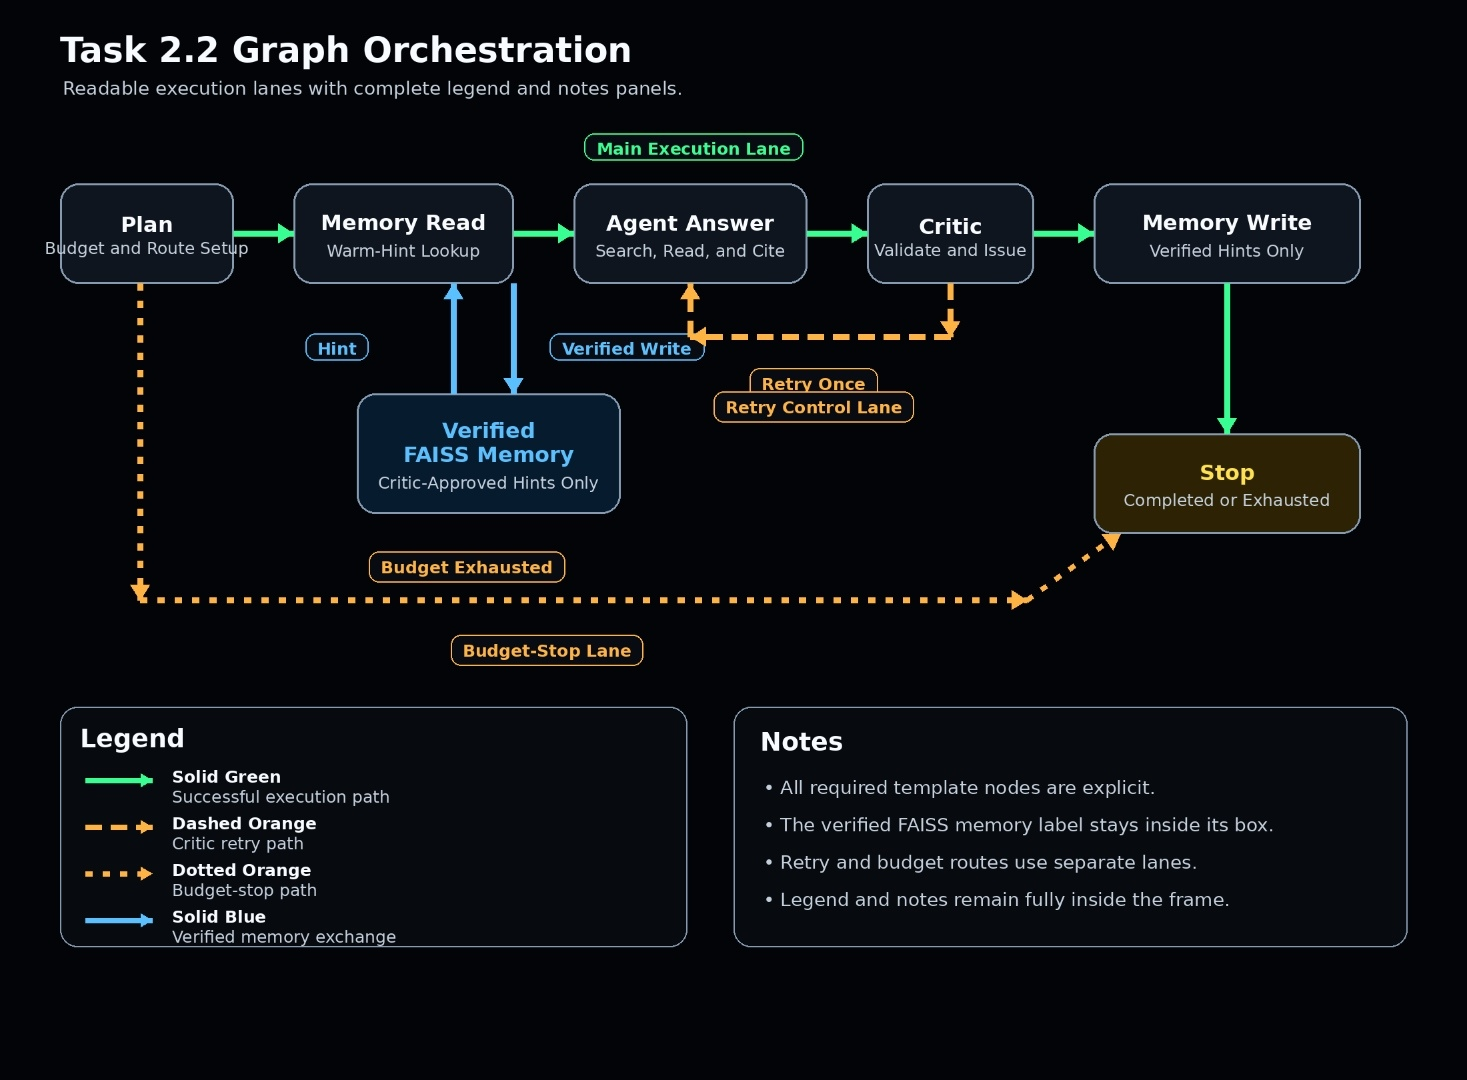

In [36]:
from IPython.display import Image, display

# Display the pre-generated graph orchestration PNG image
display(Image(filename='/content/Week27_Task_2_2_Graph_Orchestration.png'))

# Task 2.3 — Critic
The critic returns the required JSON shape: `{"valid": bool, "issues": []}`. It checks document-token presence, quotation presence, document existence, and whether a stored quotation occurs in the cited source.

In [37]:
good_verdict = critic.evaluate(agent.answer("What is the India meal allowance?"))
bad_result = type(valid)("Employees may claim anything they want.", [], [])
print("GOOD:", json.dumps(good_verdict, indent=2))
print("BAD:", json.dumps(critic.evaluate(bad_result), indent=2))

GOOD: {
  "valid": true,
  "issues": []
}
BAD: {
  "valid": false,
  "issues": [
    "missing_doc_id",
    "missing_quote"
  ]
}


# Task 2.4 — PyTests and Submission Evidence
The tests cover retrieval, typed errors, acceptance, recovery, verified memory, and the graph budget. Running them inside the notebook confirms that the same modular files included in the ZIP work in Colab.

In [38]:
import pytest
exit_code = pytest.main(["-q", "tests"])
print("pytest exit code:", exit_code)
assert exit_code == 0

......                                                                   [100%]
6 passed in 0.04s
pytest exit code: 0


# Results and Observations

- Direct employee wording works well because the corpus contains distinctive terms such as MFA, VPN, carry-over, and meal allowance.
- The leave-policy case is important because retrieval sees both versions; explicit superseded-version handling prevents an old policy from becoming the answer.
- Exact document tokens and short quotations make the grounding contract easy to inspect.
- Verified memory reduces the warm route, but source re-reading keeps the answer grounded.
- Explicit budgets make failures safe and easy to test.
- Actual latency depends on the Colab runtime, so the CSV produced by this notebook is the correct evidence for the submitted run.

## Limitations

- TF-IDF depends mainly on vocabulary overlap and does not provide deep semantic understanding.
- Memory is in-process and resets when the runtime restarts.
- The critic verifies citations and quotations, but it is not a complete natural-language entailment "MS-SQL".
- Extractive answers are reproducible but less conversational than a constrained LLM.

## Possible Extension

If I extended the work, I would compare TF-IDF against sentence-transformer embeddings, add "MS-SQL" checkpointing, and validate every individual claim against its cited sentence. I would retain the same typed error, trace, critic gate, retry limit, and budget tests.

### MS-SQL Production Architecture Details

When deploying the policy assistant engine in an enterprise production environment using **Microsoft SQL Server (MS-SQL)**, the system gains several critical capabilities:

1. **Concurrency and Transaction Isolation**
   * **MS-SQL Server** manages multi-user environments seamlessly. It utilizes advanced locking strategies (such as row-level locking with `ROWLOCK` hints) and snapshot isolation levels to prevent dirty reads, non-repeatable reads, or session blocking when multiple instances of the policy assistant agent write memory facts concurrently.

2. **State Persistence & Durability**
   * **MS-SQL Server** offers transaction log auditing and durable point-in-time recovery. This guarantees that all verified memory facts and execution agent traces are permanently stored and protected against ephemeral host failures, container lifecycle changes, or server crashes.

# Project Summary
In this project, I built a complete local Policy Assistant around the supplied dataset. I implemented FAISS retrieval, policy tools, deterministic ReAct-style traces, bad-ID recovery, verified-only memory, a budgeted graph with one critic retry, structured evaluation logs, and PyTests.

The main learning for me was that reliable agent behaviour depends on the route around the answer as much as the answer itself. Search, source reading, exact citations, verification, memory write conditions, retry limits, and stop rules each remove a different failure mode. The final system is intentionally lightweight, but its behaviour is visible, reproducible, and easy to test.

#**Thank you for evaluating            Week27_Graded_Mini_Project_[Vivek-Bhushan]**